<a href="https://colab.research.google.com/github/Nihcas001/data_analysis_using_Python/blob/main/08(C)_Smart_City_Project_using_Seaborn/smart_city_using_seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1 — Import Libraries**

In [1]:
# Import Pandas for data manipulation
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Import Seaborn for statistical visualization
import seaborn as sns

# Import Matplotlib for additional plot customization
import matplotlib.pyplot as plt

**Step 2 — Load the Dataset**

In [2]:
# Load the Smart City dataset
df = pd.read_csv("smart_city_urban_dataset.csv")

# Display the first five records
df.head()

,Month,District,Traffic_Volume,AQI,Population,Waste_kg_day,Green_Cover_Percent,Water_LPCD,Electricity_kWh_Per_Month,Traffic_Accidents,Public_Transport_Percent
0,2025-01,Central,33795,137,153694,129533.0,31.9,100.3,217.4,12,52.6
1,2025-01,North,62131,148,66023,53502.0,10.3,173.9,405.3,3,35.9
2,2025-01,South,71707,102,209765,115964.0,8.9,148.2,276.0,29,83.4
3,2025-01,East,77150,95,117435,88745.0,31.7,86.0,325.8,22,52.0
4,2025-01,West,28627,133,289931,224788.0,23.4,82.1,235.4,29,51.4


**Step 3 — Understand the Dataset**

In [3]:
# Display number of rows and columns
print(df.shape)

(120, 11)


In [4]:
# Display all column names
print(df.columns)

Index(['Month', 'District', 'Traffic_Volume', 'AQI', 'Population',
       'Waste_kg_day', 'Green_Cover_Percent', 'Water_LPCD',
       'Electricity_kWh_Per_Month', 'Traffic_Accidents',
       'Public_Transport_Percent'],
      dtype='object')


In [5]:
# Display data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Month                      120 non-null    object 
 1   District                   120 non-null    object 
 2   Traffic_Volume             120 non-null    int64  
 3   AQI                        120 non-null    int64  
 4   Population                 120 non-null    int64  
 5   Waste_kg_day               120 non-null    float64
 6   Green_Cover_Percent        120 non-null    float64
 7   Water_LPCD                 120 non-null    float64
 8   Electricity_kWh_Per_Month  120 non-null    float64
 9   Traffic_Accidents          120 non-null    int64  
 10  Public_Transport_Percent   120 non-null    float64
dtypes: float64(5), int64(4), object(2)
memory usage: 10.4+ KB


In [6]:
# Generate descriptive statistics
df.describe()

,Traffic_Volume,AQI,Population,Waste_kg_day,Green_Cover_Percent,Water_LPCD,Electricity_kWh_Per_Month,Traffic_Accidents,Public_Transport_Percent
count,120.00000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,52863.27500,125.108333,174754.508333,129520.333333,25.805000,145.379167,298.569167,19.108333,54.618333
std,19701.50497,45.491119,73548.621530,58929.327129,11.335864,38.194874,73.979693,10.662741,15.691035
min,18302.00000,45.000000,51917.000000,31760.000000,8.100000,80.700000,180.700000,2.000000,25.800000
25%,34533.00000,87.500000,102600.250000,87260.500000,16.275000,113.225000,224.675000,10.000000,43.100000
50%,53382.50000,129.500000,178875.500000,128024.500000,23.500000,142.450000,299.200000,18.000000,55.400000
75%,70939.50000,163.000000,234915.250000,169717.500000,35.800000,176.775000,360.875000,29.000000,65.625000
max,84842.00000,208.000000,298930.000000,281632.000000,48.000000,209.600000,419.300000,37.000000,84.800000


**Step 4 — Set Seaborn Style**

Seaborn provides built-in visualization themes.

In [7]:
# Set a clean visualization style
sns.set_style("whitegrid")

# Set the default figure size
sns.set_context("notebook")

**Common styles include:**
```
sns.set_style("whitegrid")
sns.set_style("darkgrid")
sns.set_style("white")
sns.set_style("dark")
sns.set_style("ticks")
```

For teaching and data analysis, whitegrid is usually a good starting point.

### **Visualization 1 — Distribution of AQI**

First, let's understand the distribution of air quality values.

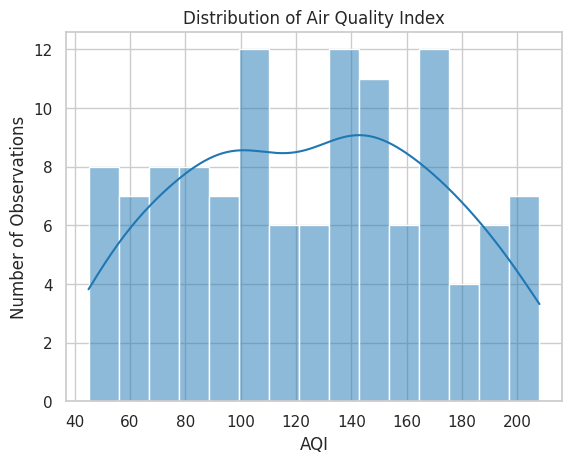

In [8]:
# Plot the distribution of AQI values
sns.histplot(data=df, x="AQI", bins=15, kde=True)

# Add labels and title
plt.title("Distribution of Air Quality Index")
plt.xlabel("AQI")
plt.ylabel("Number of Observations")

plt.show()

**What does this tell us?**

The histogram shows:

* How AQI values are distributed
* Whether values are concentrated around a particular range
* Whether extreme AQI values exist

The **kde=True** adds a smooth density curve.

### **Histogram vs KDE**

You can also create a KDE plot separately.

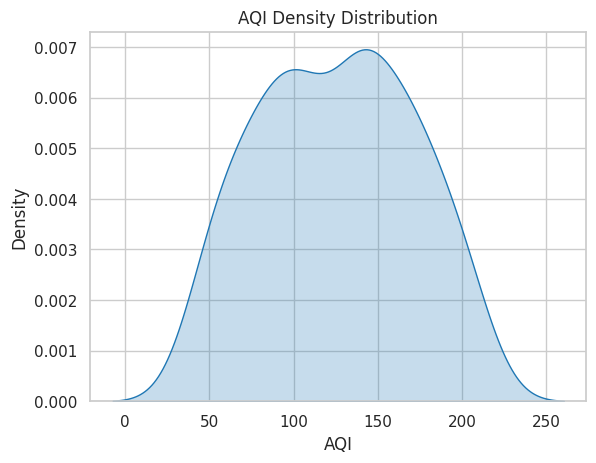

In [9]:
# Plot a smooth probability density curve for AQI
sns.kdeplot(data=df, x="AQI", fill=True)

plt.title("AQI Density Distribution")
plt.xlabel("AQI")
plt.show()

**Difference**

**Histogram:** Shows frequency using bars.

**KDE:** Shows the estimated probability density as a smooth curve.

### **Visualization 2 — Traffic by District**

Now let's determine which districts experience the highest traffic.

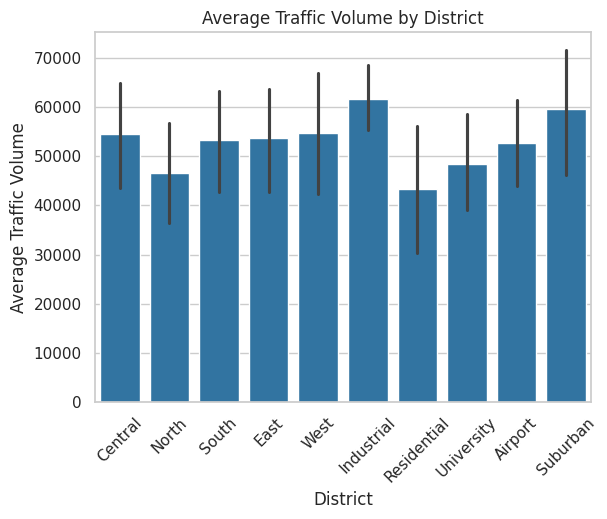

In [10]:
# Create a bar chart of average traffic by district
sns.barplot(
    data=df,
    x="District",
    y="Traffic_Volume",
    estimator="mean"
)

plt.title("Average Traffic Volume by District")
plt.xlabel("District")
plt.ylabel("Average Traffic Volume")

# Rotate district names for readability
plt.xticks(rotation=45)

plt.show()

This is a good example of categorical data visualization.

### **Visualization 3 — Traffic Trend Over Time**

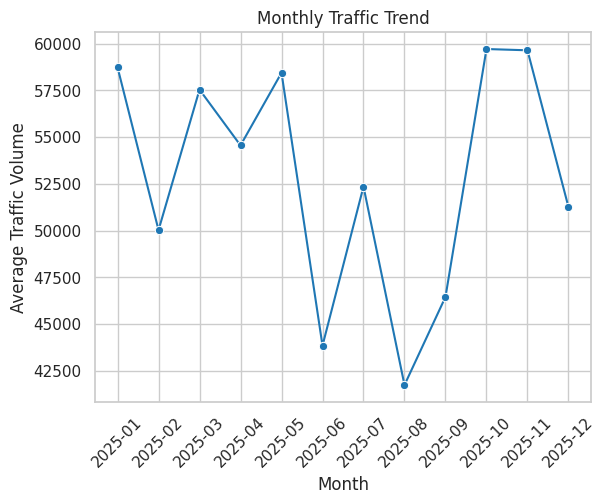

In [11]:
# Calculate average traffic for each month
monthly_traffic = (
    df.groupby("Month")["Traffic_Volume"]
      .mean()
      .reset_index()
)

# Plot the monthly trend
sns.lineplot(
    data=monthly_traffic,
    x="Month",
    y="Traffic_Volume",
    marker="o"
)

plt.title("Monthly Traffic Trend")
plt.xlabel("Month")
plt.ylabel("Average Traffic Volume")

plt.xticks(rotation=45)

plt.show()

This allows the smart-city authority to identify months with unusually high traffic.

## **Visualization 4 — AQI by District**

A box plot is particularly useful when we want to understand variation and outliers.

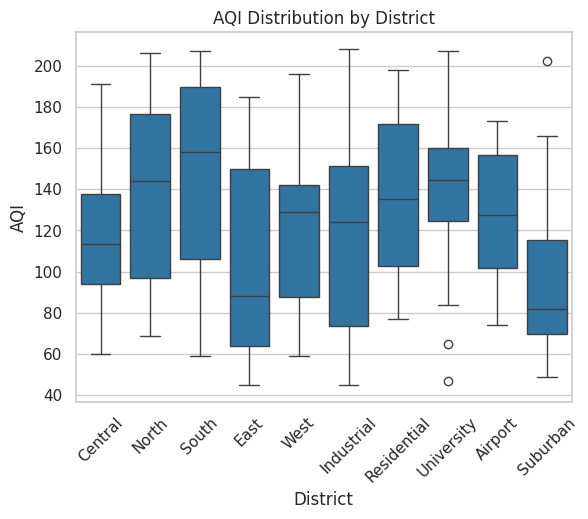

In [12]:
# Compare AQI distributions across districts
sns.boxplot(
    data=df,
    x="District",
    y="AQI"
)

plt.title("AQI Distribution by District")
plt.xlabel("District")
plt.ylabel("AQI")

plt.xticks(rotation=45)

plt.show()

**What does a box plot show?**

A box plot can reveal:

* Median
* Lower quartile
* Upper quartile
* Spread
* Potential outliers

This is more informative than simply calculating the average.

### **Visualization 5 — Violin Plot**

> A violin plot combines distribution information with summary statistics.

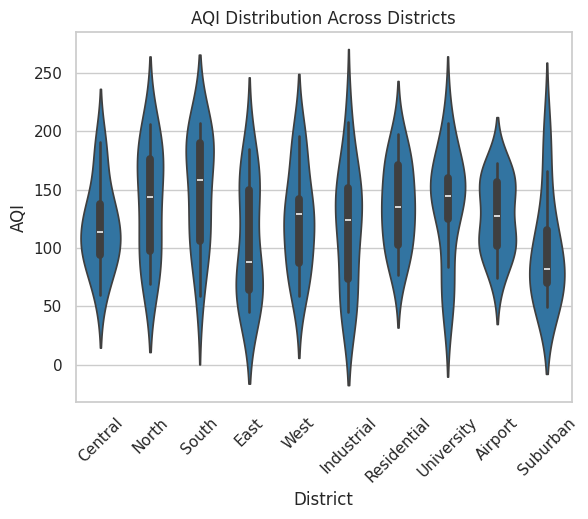

In [13]:
# Visualize AQI distribution using violin plots
sns.violinplot(
    data=df,
    x="District",
    y="AQI"
)

plt.title("AQI Distribution Across Districts")
plt.xlabel("District")
plt.ylabel("AQI")

plt.xticks(rotation=45)

plt.show()

**Box plot vs violin plot**

| Box Plot            | Violin Plot                    |
| ------------------- | ------------------------------ |
| Shows quartiles     | Shows quartiles                |
| Shows median        | Shows median                   |
| Shows outliers      | Shows distribution shape       |
| More compact        | More detailed                  |
| Good for comparison | Good for distribution analysis |


### **Visualization 6 — Traffic vs Air Quality**

This is one of the most interesting relationships in our dataset.

**Question:**

> Does higher traffic appear to be associated with poorer air quality?

Use a scatter plot.

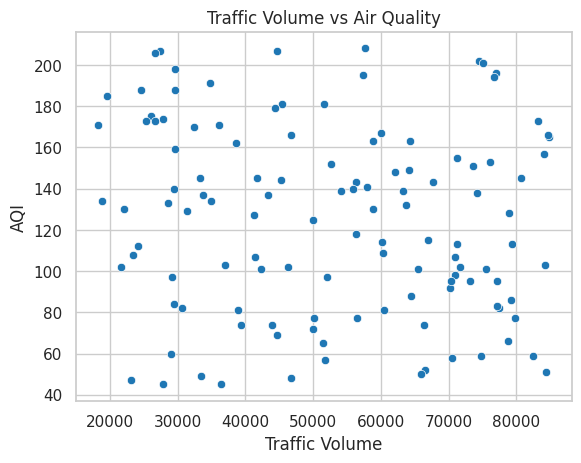

In [14]:
# Compare traffic volume with AQI
sns.scatterplot(
    data=df,
    x="Traffic_Volume",
    y="AQI"
)

plt.title("Traffic Volume vs Air Quality")
plt.xlabel("Traffic Volume")
plt.ylabel("AQI")

plt.show()

Each point represents one district-month observation.

### **Visualization 7 — Regression Plot**

Seaborn can automatically add a regression line.

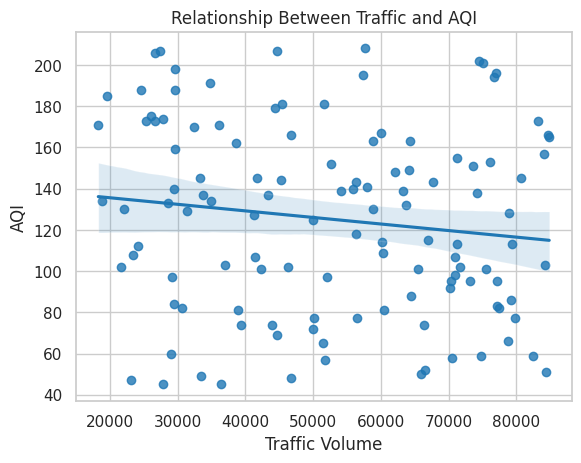

In [15]:
# Plot traffic and AQI with a regression line
sns.regplot(
    data=df,
    x="Traffic_Volume",
    y="AQI"
)

plt.title("Relationship Between Traffic and AQI")
plt.xlabel("Traffic Volume")
plt.ylabel("AQI")

plt.show()

This helps students visually investigate whether the two variables have a positive or negative relationship.

**Important:** A regression line does not prove that traffic causes poor air quality. It only shows an observed statistical relationship.

### **Visualization 8 — Traffic by District and Month**

We can use **hue** to introduce another categorical variable.

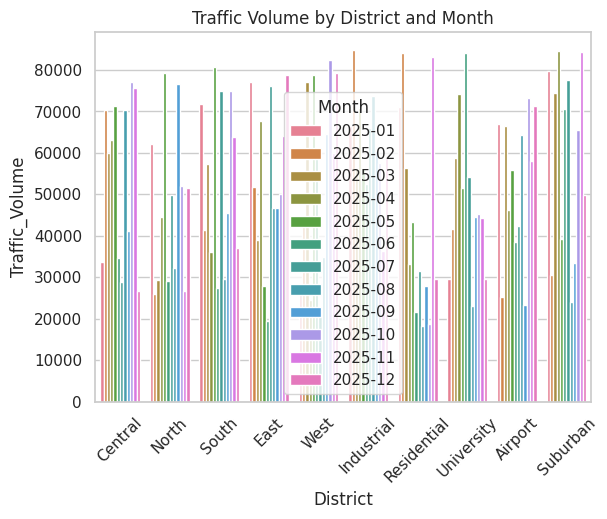

In [16]:
# Compare traffic across districts and months
sns.barplot(
    data=df,
    x="District",
    y="Traffic_Volume",
    hue="Month"
)

plt.title("Traffic Volume by District and Month")
plt.xticks(rotation=45)

plt.show()

However, because there are 12 months, the plot can become crowded.

A better visualization is often a **heatmap.**

### **Visualization 9 — Traffic Heatmap**

First, create a pivot table.

In [17]:
# Calculate average traffic for each district and month
traffic_pivot = df.pivot_table(
    values="Traffic_Volume",
    index="District",
    columns="Month",
    aggfunc="mean"
)

traffic_pivot


Month,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
District,,,,,,,,,,,,
Airport,66984.0,25392.0,66404.0,46251.0,55841.0,38559.0,42285.0,64271.0,23415.0,73176.0,57986.0,71302.0
Central,33795.0,70256.0,60107.0,63236.0,71222.0,34779.0,28975.0,70329.0,41275.0,77207.0,75545.0,26705.0
East,77150.0,51827.0,38932.0,67689.0,27823.0,19542.0,76141.0,46732.0,46746.0,50154.0,64163.0,78774.0
Industrial,66555.0,84842.0,56360.0,70921.0,56304.0,52578.0,65926.0,73645.0,60533.0,57666.0,36449.0,58809.0
North,62131.0,26110.0,29411.0,44641.0,79389.0,29130.0,49921.0,32388.0,76656.0,52016.0,26666.0,51572.0
Residential,70995.0,84199.0,56467.0,33338.0,43351.0,21709.0,31456.0,18302.0,27865.0,18814.0,83155.0,29664.0
South,71707.0,41419.0,57384.0,36070.0,80752.0,27348.0,75043.0,29637.0,45446.0,74819.0,63765.0,37063.0
Suburban,79858.0,30688.0,74491.0,84617.0,39352.0,70528.0,77494.0,24168.0,33524.0,65523.0,84358.0,49987.0
University,29534.0,41664.0,58818.0,74179.0,51496.0,84040.0,54187.0,23126.0,44614.0,45306.0,44399.0,29555.0


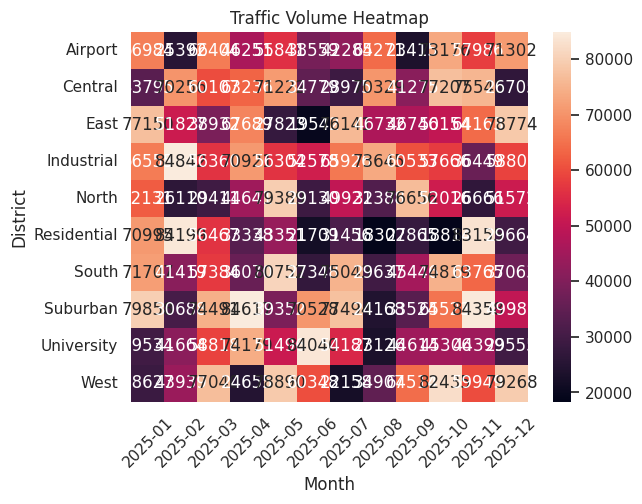

In [18]:
# Visualize traffic intensity using a heatmap
sns.heatmap(
    traffic_pivot,
    annot=True,
    fmt=".0f"
)

plt.title("Traffic Volume Heatmap")
plt.xlabel("Month")
plt.ylabel("District")

plt.xticks(rotation=45)

plt.show()

**How to interpret it**

Each cell represents the average traffic volume for:

> **One district + one month**

This makes it easy to identify traffic hotspots and peak months.

### **Visualization 10 — Correlation Heatmap**

This is one of the most important visualizations for the project.

First calculate correlations.

In [19]:
# Select numerical columns
numeric_df = df.select_dtypes(include="number")

# Calculate correlation matrix
correlation = numeric_df.corr()

correlation

,Traffic_Volume,AQI,Population,Waste_kg_day,Green_Cover_Percent,Water_LPCD,Electricity_kWh_Per_Month,Traffic_Accidents,Public_Transport_Percent
Traffic_Volume,1.000000,-0.137931,0.001037,-0.002185,-0.028522,0.018530,0.060298,0.049725,0.064166
AQI,-0.137931,1.000000,0.102408,0.055837,0.014518,0.104116,-0.157985,-0.047874,-0.108004
Population,0.001037,0.102408,1.000000,0.922353,-0.004768,-0.003268,-0.089281,-0.005439,-0.022666
Waste_kg_day,-0.002185,0.055837,0.922353,1.000000,-0.007782,-0.042242,-0.096867,0.020936,-0.073618
Green_Cover_Percent,-0.028522,0.014518,-0.004768,-0.007782,1.000000,0.113477,0.010790,0.034715,0.041606
Water_LPCD,0.018530,0.104116,-0.003268,-0.042242,0.113477,1.000000,0.067618,0.001545,0.096392
Electricity_kWh_Per_Month,0.060298,-0.157985,-0.089281,-0.096867,0.010790,0.067618,1.000000,-0.090890,0.167446
Traffic_Accidents,0.049725,-0.047874,-0.005439,0.020936,0.034715,0.001545,-0.090890,1.000000,-0.034824
Public_Transport_Percent,0.064166,-0.108004,-0.022666,-0.073618,0.041606,0.096392,0.167446,-0.034824,1.000000


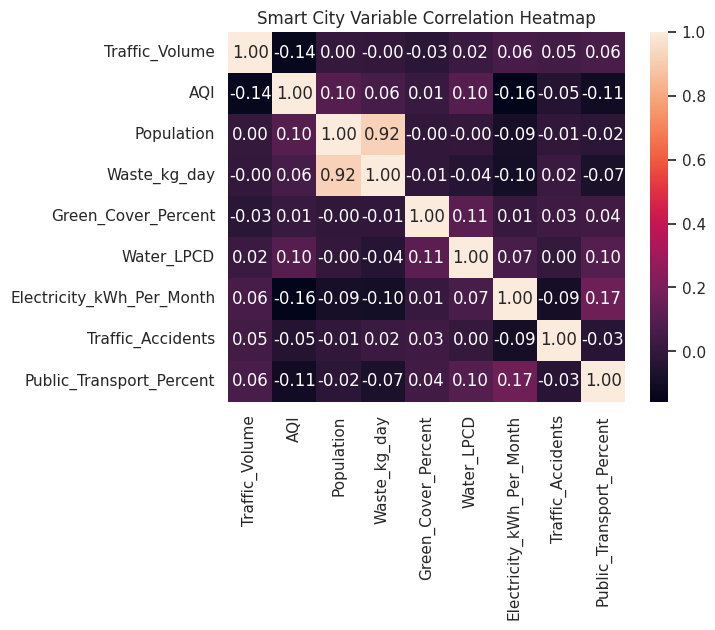

In [20]:
# Display correlations using a heatmap
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Smart City Variable Correlation Heatmap")

plt.show()

**Correlation values**

Values range approximately from:
```
-1  → Strong negative relationship
 0  → Little/no linear relationship
+1  → Strong positive relationship
```
For example:

> Traffic_Volume ↔ AQI

can be investigated to determine whether higher traffic tends to occur alongside higher AQI.

### **Visualization 11 — Population vs Waste**

A smart city also needs to understand waste generation.

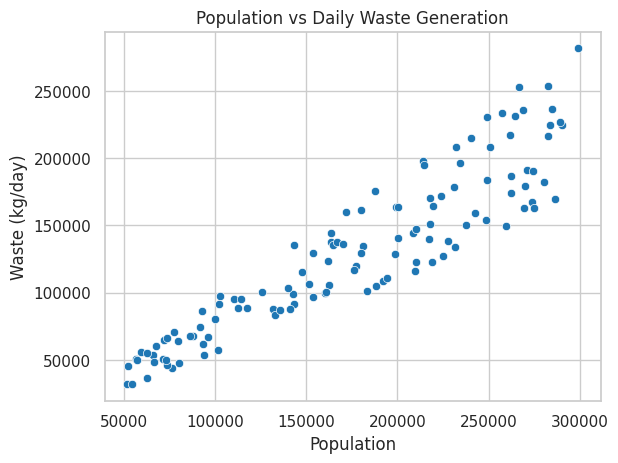

In [21]:
# Compare population with daily waste generation
sns.scatterplot(
    data=df,
    x="Population",
    y="Waste_kg_day"
)

plt.title("Population vs Daily Waste Generation")
plt.xlabel("Population")
plt.ylabel("Waste (kg/day)")

plt.show()

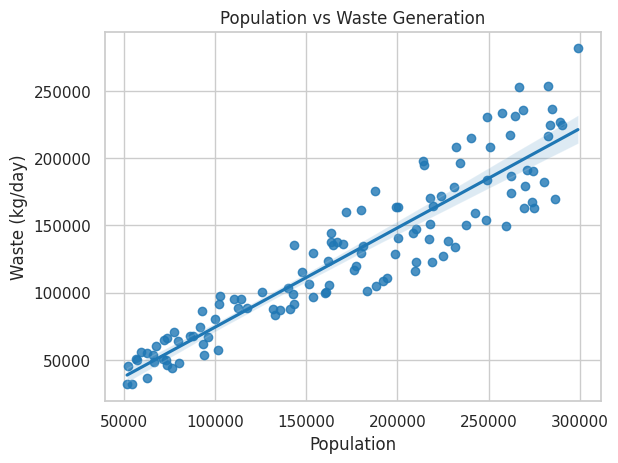

In [22]:
# Add regression trend to population-waste relationship
sns.regplot(
    data=df,
    x="Population",
    y="Waste_kg_day"
)

plt.title("Population vs Waste Generation")
plt.xlabel("Population")
plt.ylabel("Waste (kg/day)")

plt.show()

### **Visualization 12 — Green Coverage vs AQI**

This is another interesting smart-city question:

> Do districts with more green coverage tend to have lower AQI?

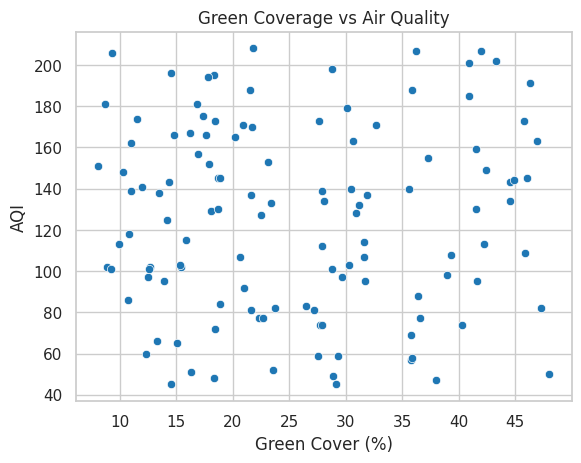

In [23]:
# Examine relationship between green coverage and AQI
sns.scatterplot(
    data=df,
    x="Green_Cover_Percent",
    y="AQI"
)

plt.title("Green Coverage vs Air Quality")
plt.xlabel("Green Cover (%)")
plt.ylabel("AQI")

plt.show()

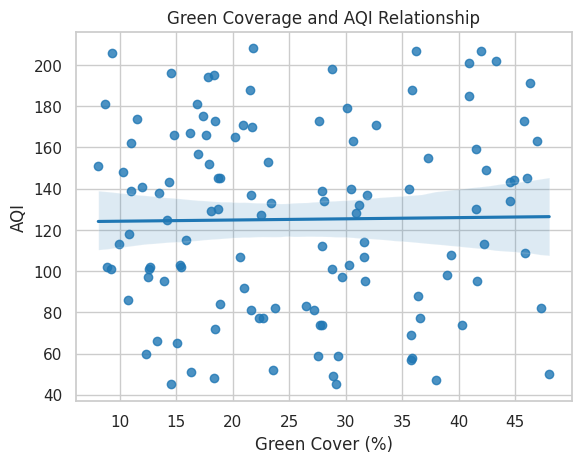

In [24]:
# Show the overall relationship using regression line
sns.regplot(
    data=df,
    x="Green_Cover_Percent",
    y="AQI"
)

plt.title("Green Coverage and AQI Relationship")
plt.xlabel("Green Cover (%)")
plt.ylabel("AQI")

plt.show()

Again, students should understand that correlation does not establish causation.

### **Visualization 13 — Public Transport Usage**

Let's compare public transport usage across districts.

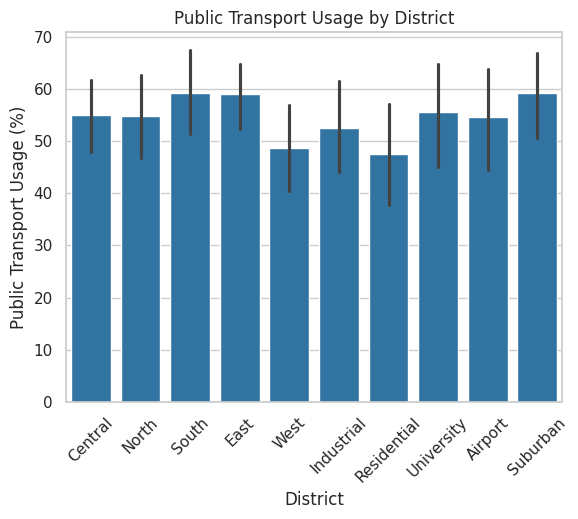

In [25]:
# Compare public transport usage across districts
sns.barplot(
    data=df,
    x="District",
    y="Public_Transport_Percent"
)

plt.title("Public Transport Usage by District")
plt.xlabel("District")
plt.ylabel("Public Transport Usage (%)")

plt.xticks(rotation=45)

plt.show()

This could help city planners identify districts where public transport adoption is relatively low.

### **Visualization 14 — Accidents by District**

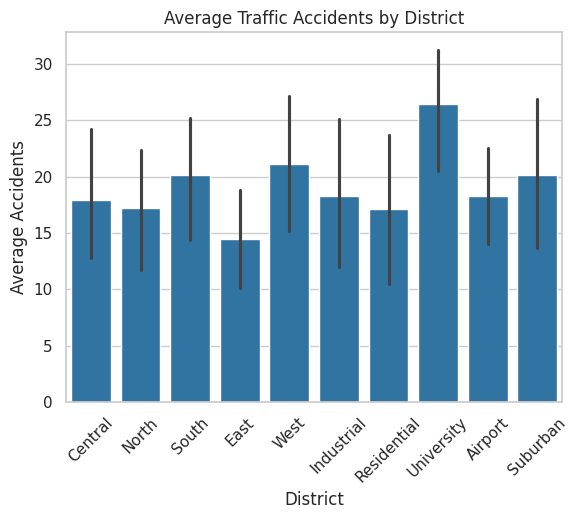

In [26]:
# Compare average traffic accidents across districts
sns.barplot(
    data=df,
    x="District",
    y="Traffic_Accidents"
)

plt.title("Average Traffic Accidents by District")
plt.xlabel("District")
plt.ylabel("Average Accidents")

plt.xticks(rotation=45)

plt.show()

### **Visualization 15 — Pair Plot**

Seaborn's **pairplot()** is extremely useful for exploratory data analysis.

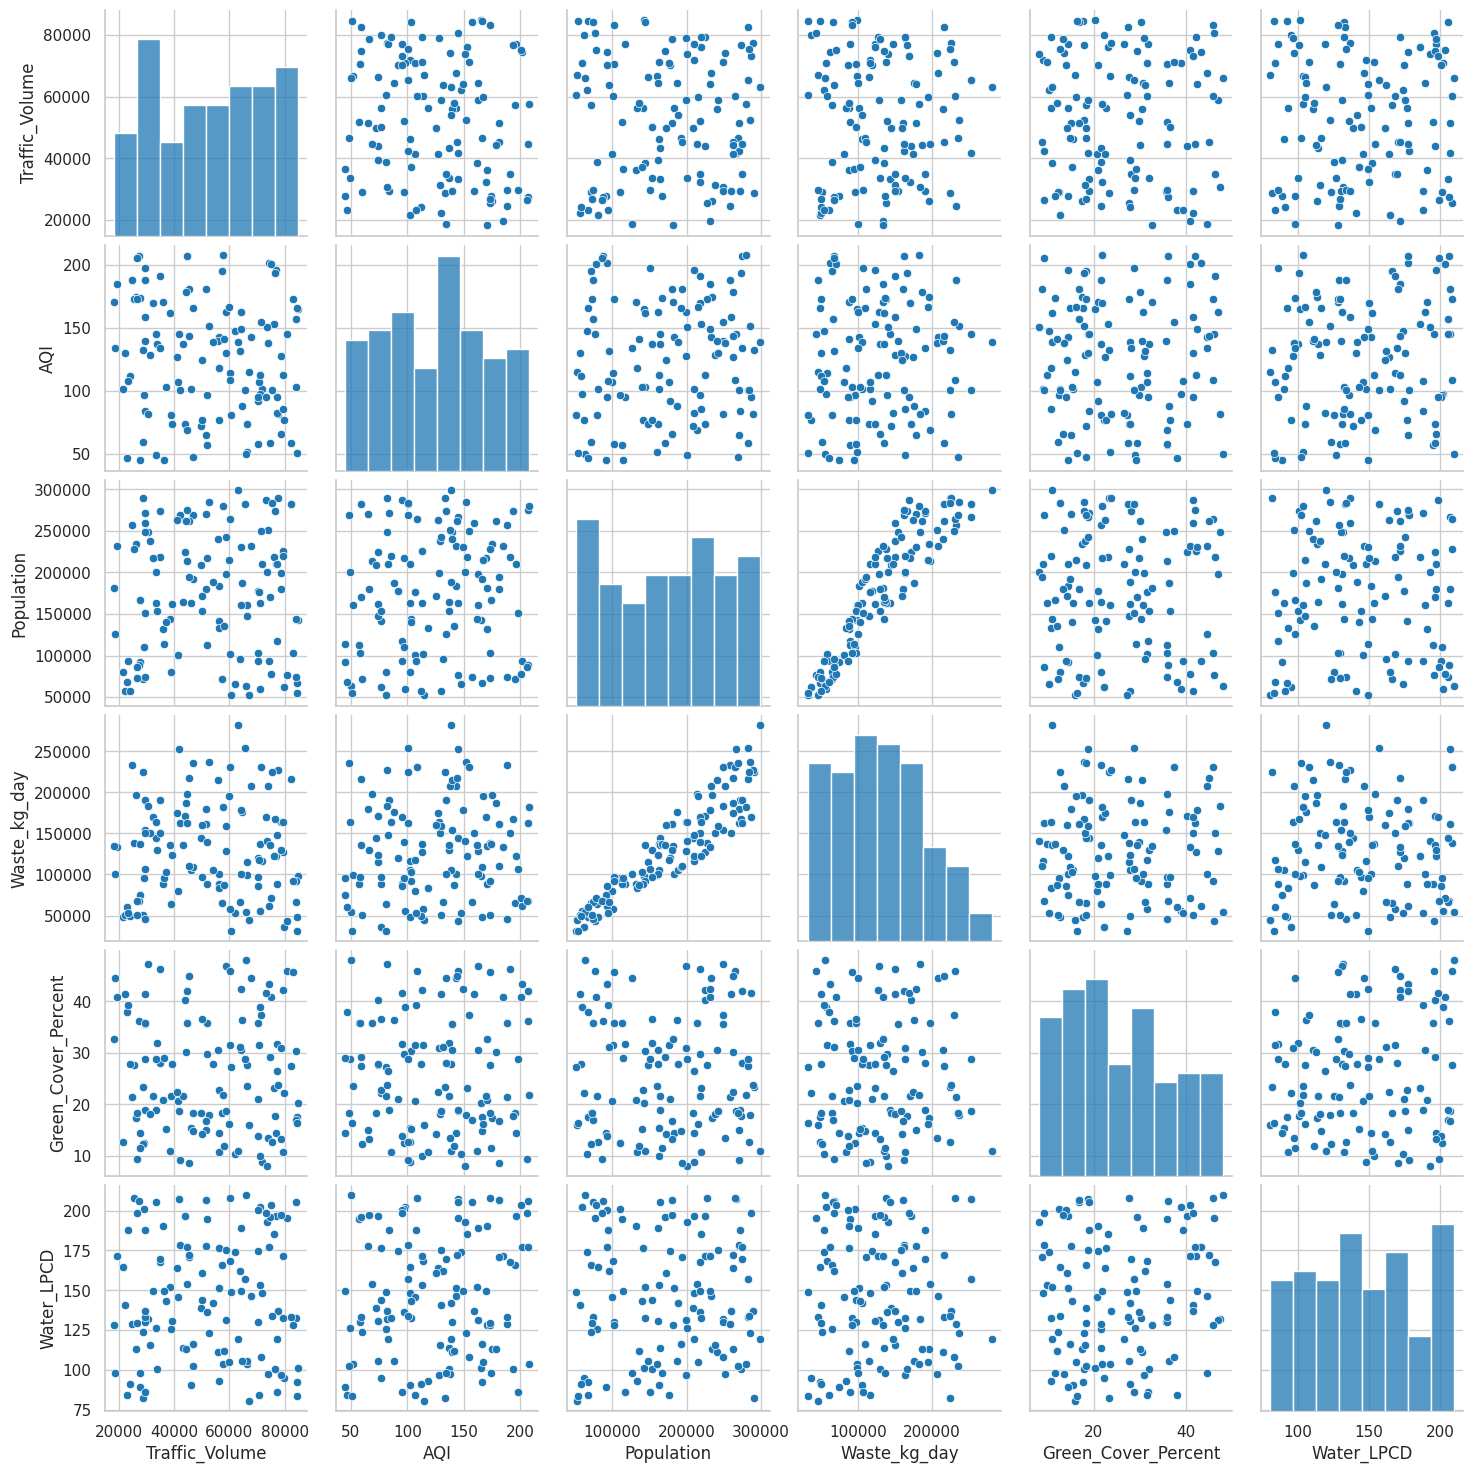

In [27]:
# Select important urban variables
selected_columns = [
    "Traffic_Volume",
    "AQI",
    "Population",
    "Waste_kg_day",
    "Green_Cover_Percent",
    "Water_LPCD"
]

# Create pairwise visualizations
sns.pairplot(df[selected_columns])

plt.show()

This creates multiple plots showing relationships between variables.

Students can use it to quickly investigate:

* Traffic vs AQI
* Population vs waste
* Green coverage vs AQI
* Water consumption vs population
* etc.

### **Visualization 16 — Pair Plot by District**

We can use **hue**.

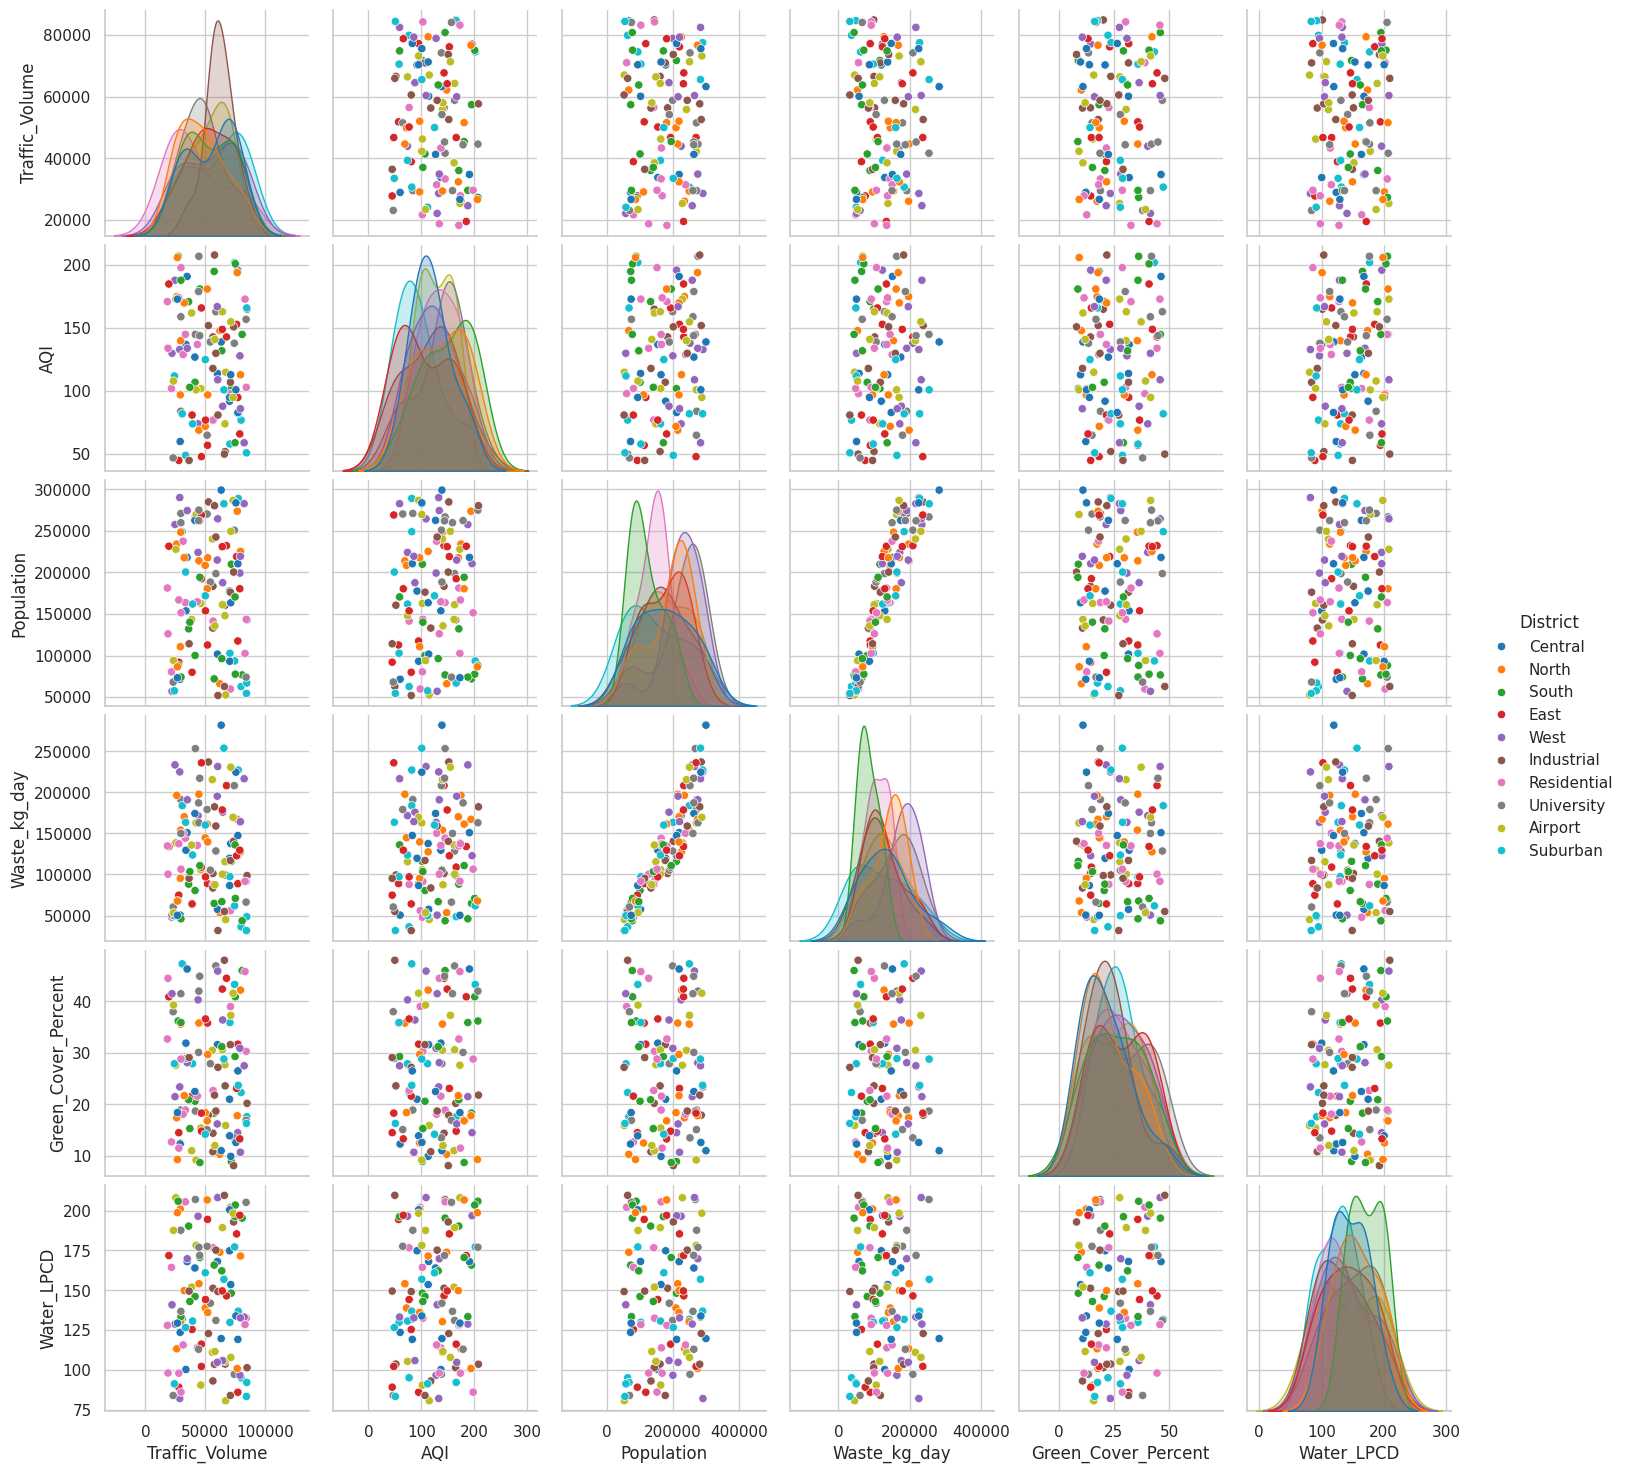

In [28]:
# Compare variable relationships across districts
sns.pairplot(
    df[selected_columns + ["District"]],
    hue="District"
)

plt.show()

This demonstrates one of the major strengths of Seaborn: **visualizing relationships while considering categorical variables.**

### **Advanced Concept — hue**

Students should understand hue very well.

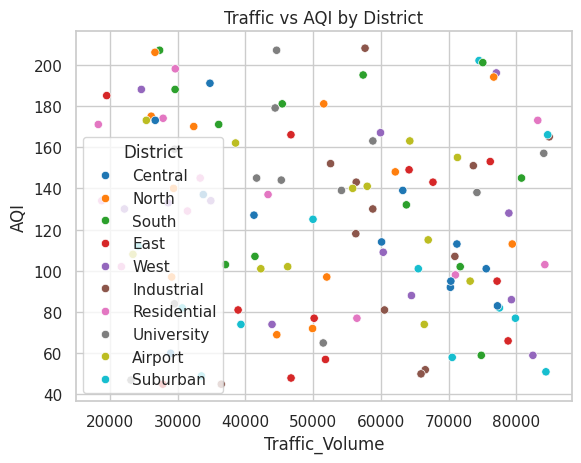

In [29]:
sns.scatterplot(
    data=df,
    x="Traffic_Volume",
    y="AQI",
    hue="District"
)

plt.title("Traffic vs AQI by District")
plt.show()

Without hue:

> Traffic → AQI

With hue:

> Traffic → AQI for **different districts**

This adds another dimension to the visualization.

### **Advanced Concept — style**

We can also use marker styles.

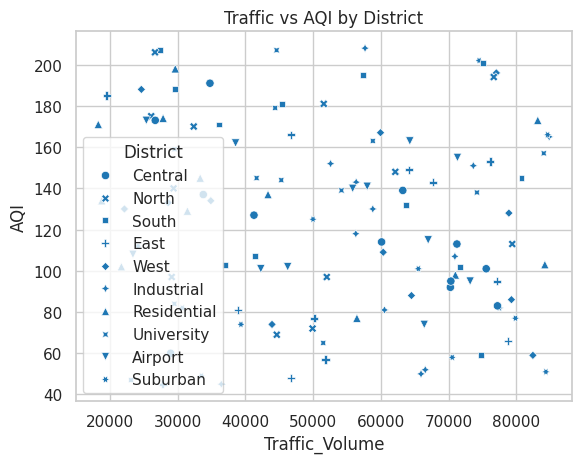

In [30]:
# Different marker styles represent different districts
sns.scatterplot(
    data=df,
    x="Traffic_Volume",
    y="AQI",
    style="District"
)

plt.title("Traffic vs AQI by District")
plt.show()

### **Advanced Concept — size**

We can represent a third numerical variable using marker size.

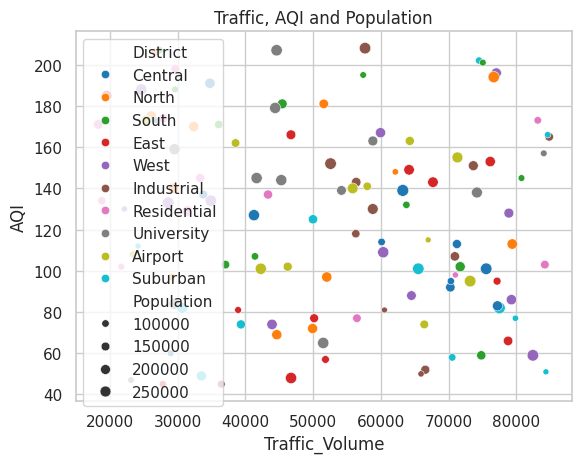

In [31]:
# Marker size represents population
sns.scatterplot(
    data=df,
    x="Traffic_Volume",
    y="AQI",
    size="Population",
    hue="District"
)

plt.title("Traffic, AQI and Population")
plt.show()

Now:

* X-axis → Traffic
* Y-axis → AQI
* Color → District
* Size → Population

This is a much more advanced visualization.

### **Advanced Concept — FacetGrid**

Seaborn can create separate plots for categories.

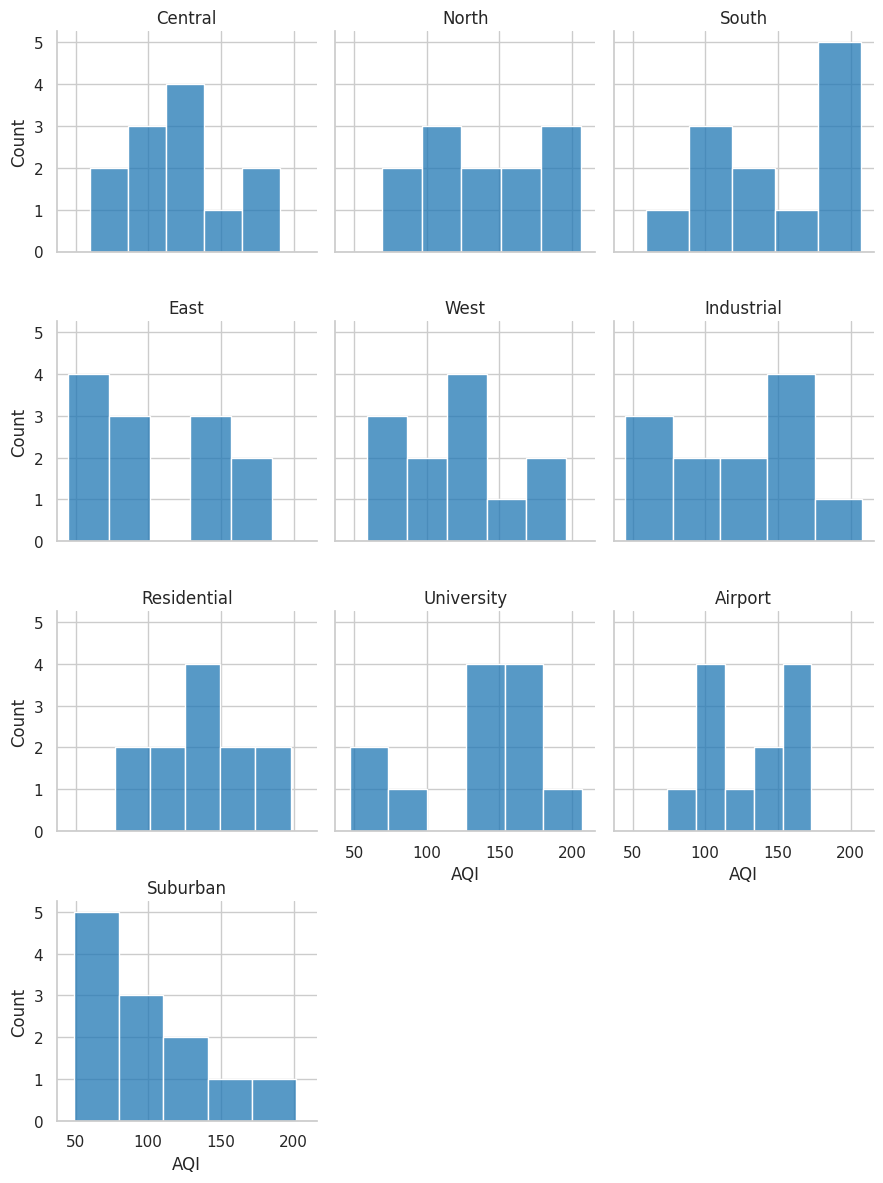

In [32]:
# Create separate AQI distributions for selected districts
g = sns.FacetGrid(
    df,
    col="District",
    col_wrap=3,
    height=3
)

# Draw histogram in each district panel
g.map_dataframe(
    sns.histplot,
    x="AQI"
)

g.set_titles("{col_name}")

plt.show()

This allows us to compare distributions across districts without putting everything into one crowded graph.

### **Mini Project Dashboard-Style Analysis**

Now students can combine the most useful visualizations into a small analytical project.

**Question 1 — Which districts have the highest traffic?**

In [33]:
# Calculate average traffic by district
traffic_by_district = (
    df.groupby("District")["Traffic_Volume"]
      .mean()
      .sort_values(ascending=False)
)

print(traffic_by_district)

District
Industrial     61715.666667
Suburban       59549.000000
West           54727.500000
Central        54452.583333
East           53806.083333
South          53371.083333
Airport        52655.500000
University     48409.833333
North          46669.250000
Residential    43276.250000
Name: Traffic_Volume, dtype: float64


**Question 2 — Which districts have the poorest air quality?**

In [34]:
# Calculate average AQI by district
aqi_by_district = (
    df.groupby("District")["AQI"]
      .mean()
      .sort_values(ascending=False)
)

print(aqi_by_district)

District
South          149.250000
North          138.500000
Residential    136.750000
University     135.583333
Airport        127.416667
West           124.333333
Central        118.750000
Industrial     116.833333
East           105.416667
Suburban        98.250000
Name: AQI, dtype: float64


**Question 3 — Which districts generate the most waste?**

In [35]:
# Calculate average daily waste by district
waste_by_district = (
    df.groupby("District")["Waste_kg_day"]
      .mean()
      .sort_values(ascending=False)
)

print(waste_by_district)

District
West           178367.333333
University     159073.666667
North          139571.000000
Central        134197.333333
Airport        130007.833333
East           127619.250000
Suburban       119790.250000
Industrial     116700.666667
Residential    106970.166667
South           82905.833333
Name: Waste_kg_day, dtype: float64


**Question 4 — Which districts have the most green coverage?**

In [36]:
# Calculate average green coverage
green_by_district = (
    df.groupby("District")["Green_Cover_Percent"]
      .mean()
      .sort_values(ascending=False)
)

print(green_by_district)

District
University     29.533333
East           28.125000
West           28.075000
Suburban       27.841667
Residential    27.216667
South          26.016667
Airport        24.841667
Industrial     22.616667
North          22.291667
Central        21.491667
Name: Green_Cover_Percent, dtype: float64


### **A More Advanced Visualization**

Let's visualize the relationship between traffic, AQI, and district.

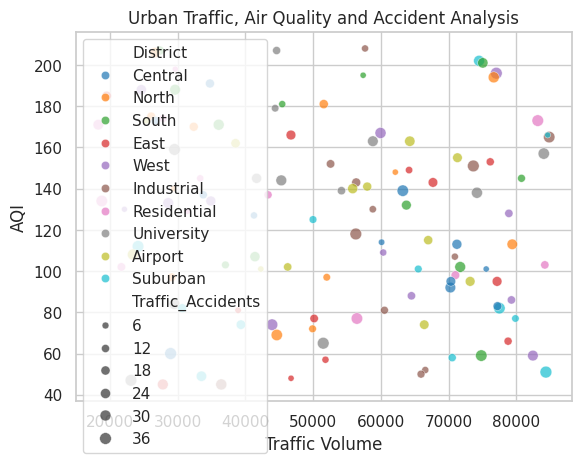

In [37]:
# Compare traffic and AQI while distinguishing districts
sns.scatterplot(
    data=df,
    x="Traffic_Volume",
    y="AQI",
    hue="District",
    size="Traffic_Accidents",
    alpha=0.7
)

plt.title("Urban Traffic, Air Quality and Accident Analysis")
plt.xlabel("Traffic Volume")
plt.ylabel("AQI")

plt.show()

Here:

| Visual element | Represents        |
| -------------- | ----------------- |
| X-axis         | Traffic           |
| Y-axis         | AQI               |
| Color          | District          |
| Bubble size    | Traffic accidents |

This is a good example of multivariate visualization.

### **Important Seaborn Functions Students Should Know**

I would give your students this cheat sheet:

| Function            | Purpose                                      |
| ------------------- | -------------------------------------------- |
| `sns.histplot()`    | Distribution                                 |
| `sns.kdeplot()`     | Density                                      |
| `sns.countplot()`   | Category counts                              |
| `sns.barplot()`     | Category vs numerical value                  |
| `sns.boxplot()`     | Distribution + outliers                      |
| `sns.violinplot()`  | Distribution shape                           |
| `sns.scatterplot()` | Relationship between numerical variables     |
| `sns.lineplot()`    | Trend over time                              |
| `sns.regplot()`     | Relationship + regression                    |
| `sns.heatmap()`     | Matrix/correlation visualization             |
| `sns.pairplot()`    | Multiple pairwise relationships              |
| `sns.FacetGrid()`   | Multiple category-wise plots                 |
| `sns.jointplot()`   | Joint distribution                           |
| `sns.stripplot()`   | Individual observations                      |
| `sns.swarmplot()`   | Individual observations without much overlap |

### **Matplotlib Functions Used Alongside Seaborn**

Even when using Seaborn, students should know basic Matplotlib commands.
```
plt.title()
plt.xlabel()
plt.ylabel()
plt.xticks()
plt.yticks()
plt.legend()
plt.grid()
plt.xlim()
plt.ylim()
plt.figure()
plt.show()
```

For example:
```
# Create a custom figure size
plt.figure(figsize=(10, 5))

# Create the Seaborn plot
sns.scatterplot(
    data=df,
    x="Traffic_Volume",
    y="AQI"
)

# Customize using Matplotlib
plt.title("Traffic Volume vs AQI", fontsize=16)
plt.xlabel("Traffic Volume")
plt.ylabel("Air Quality Index")

plt.show()
```

This is why students should learn Matplotlib + Seaborn together.